# Step 5 — DL baseline: 3D CNN on needle-aligned grid

**Task:** binary classification — GG3+ (label=1) vs GG0–2 (label=0)

**Approach:** resample each sparse point cloud `(w, u, v, I)` onto a fixed 3D grid in needle-aligned coordinates, then classify with a small 3D CNN.

**Grid design:**
- Axial (`w`): 24 bins — normalised to [0,1], matching ~1mm/layer actual sampling density
- Radial (`u`, `v`): 9 × 9 bins covering [-2, +2] mm (full 4mm cylinder diameter) at 0.5mm spacing
- Resampling: nearest-neighbour from point cloud; corners outside the 2mm cylinder radius are zeroed

**Augmentations (training only — all valid symmetries of the biopsy geometry):**
- Random rotation around the needle axis (w): the device has no preferred angular orientation
- Random radial flip (u → −u): equivalent to mirroring the radial plane
- Intensity jitter: small additive + multiplicative noise

**Same train/test split** as the baseline (`data/test_subjects.csv`); 5-fold `StratifiedGroupKFold` CV with early stopping on val AUC.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import KDTree
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score

REPO_ROOT   = Path('..').resolve()
PATCHES_DIR = REPO_ROOT / 'data' / 'patches'
MANIFEST    = REPO_ROOT / 'data' / 'manifest.csv'
DROP_LIST   = REPO_ROOT / 'data' / 'cores_to_drop_contamination.csv'
TEST_SUBJS  = REPO_ROOT / 'data' / 'test_subjects.csv'

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: mps


## 1. Load manifest & splits

In [2]:
manifest = pd.read_csv(MANIFEST)
drop_ids = set(pd.read_csv(DROP_LIST)['core_id'])
manifest = manifest[~manifest['core_id'].isin(drop_ids)].reset_index(drop=True)

extracted = {int(p.stem) for p in PATCHES_DIR.glob('*.npz')}
manifest  = manifest[manifest['core_id'].isin(extracted)].reset_index(drop=True)

# Same fixed test split as the baseline
test_subjs = set(pd.read_csv(TEST_SUBJS, header=None)[0].tolist())
manifest['split'] = manifest['subject_id'].map(
    lambda s: 'test' if s in test_subjs else 'trainval'
)

for split in ['trainval', 'test']:
    sub = manifest[manifest['split'] == split]
    pos = (sub['label'] == 1).sum()
    print(f'{split:9s}: {len(sub):6,d} cores  ({sub.subject_id.nunique():3d} subjects)'
          f'  pos={pos} ({100*pos/len(sub):.1f}%)')

trainval : 14,192 cores  (676 subjects)  pos=521 (3.7%)
test     :  2,498 cores  (120 subjects)  pos=126 (5.0%)


## 2. Point-cloud → 3D grid resampling

Grids are precomputed once and cached to `data/grids/` so the training loop only reads a flat float32 array per sample.

In [3]:
# Grid config
N_AXIAL  = 24   # bins along normalised needle axis  [0, 1]
N_RADIAL = 9    # bins along u and v                 [-2, +2] mm
RADIUS   = 2.0  # mm — cylinder radius

# Precompute fixed radial grid and circle mask (same for all cores)
_r_pts  = np.linspace(-RADIUS, RADIUS, N_RADIAL)          # (9,)
_UG, _VG = np.meshgrid(_r_pts, _r_pts, indexing='ij')     # (9, 9)
CIRCLE_MASK = (_UG**2 + _VG**2) > RADIUS**2               # corners outside cylinder

# Precompute target grid indices (normalised) for KDTree lookup
_w_pts  = np.linspace(0, 1, N_AXIAL)                      # (24,)
_WG, _UGn, _VGn = np.meshgrid(
    _w_pts,
    (_r_pts + RADIUS) / (2 * RADIUS),  # u normalised to [0,1]
    (_r_pts + RADIUS) / (2 * RADIUS),  # v normalised to [0,1]
    indexing='ij'
)  # each (24, 9, 9)
TARGET_PTS = np.stack([_WG.ravel(), _UGn.ravel(), _VGn.ravel()], axis=1)  # (24*9*9, 3)


def resample_to_grid(coords: np.ndarray, intensity: np.ndarray) -> np.ndarray:
    """
    Resample a sparse point cloud (N, 3) + intensity (N,) onto the fixed
    (N_AXIAL, N_RADIAL, N_RADIAL) grid using nearest-neighbour lookup.

    The axial coordinate w is normalised to [0,1] before lookup, so the
    grid always spans the full needle regardless of its physical length.
    Voxels outside the 2mm cylinder radius are zeroed.

    Returns: float32 array of shape (N_AXIAL, N_RADIAL, N_RADIAL)
    """
    w = coords[:, 0]
    u = coords[:, 1]
    v = coords[:, 2]

    w_norm = (w - w.min()) / (w.max() - w.min() + 1e-8)
    u_norm = (u + RADIUS) / (2 * RADIUS)
    v_norm = (v + RADIUS) / (2 * RADIUS)
    src_pts = np.stack([w_norm, u_norm, v_norm], axis=1)

    tree = KDTree(src_pts)
    _, idx = tree.query(TARGET_PTS, k=1)

    grid = intensity[idx].reshape(N_AXIAL, N_RADIAL, N_RADIAL).astype(np.float32)
    grid[:, CIRCLE_MASK] = 0.0
    return grid


# Sanity check on one core
_sample = np.load(PATCHES_DIR / f"{manifest['core_id'].iloc[0]}.npz")
_grid   = resample_to_grid(_sample['coords'], _sample['intensity'])
print(f'Grid shape : {_grid.shape}   dtype: {_grid.dtype}')
print(f'Active voxels (non-zero): {(_grid != 0).sum()} / {_grid.size}')

Grid shape : (24, 9, 9)   dtype: float32
Active voxels (non-zero): 1176 / 1944


In [4]:
GRIDS_DIR = REPO_ROOT / 'data' / 'grids'
GRIDS_DIR.mkdir(exist_ok=True)

# Only compute grids that don't exist yet (safe to re-run)
missing = [cid for cid in manifest['core_id']
           if not (GRIDS_DIR / f'{cid}.npy').exists()]

if missing:
    print(f'Precomputing {len(missing):,} grids → {GRIDS_DIR}')
    for cid in tqdm(missing, desc='Grids'):
        d = np.load(PATCHES_DIR / f'{cid}.npz')
        grid = resample_to_grid(d['coords'], d['intensity'])
        np.save(GRIDS_DIR / f'{cid}.npy', grid)
    print('Done.')
else:
    print(f'All {len(manifest):,} grids already cached in {GRIDS_DIR}')

All 16,690 grids already cached in /Users/valentinbadea/Documents/MVA/Cours_S2/projet_medecin/gleason_prediction/data/grids


### Visualise resampled grids

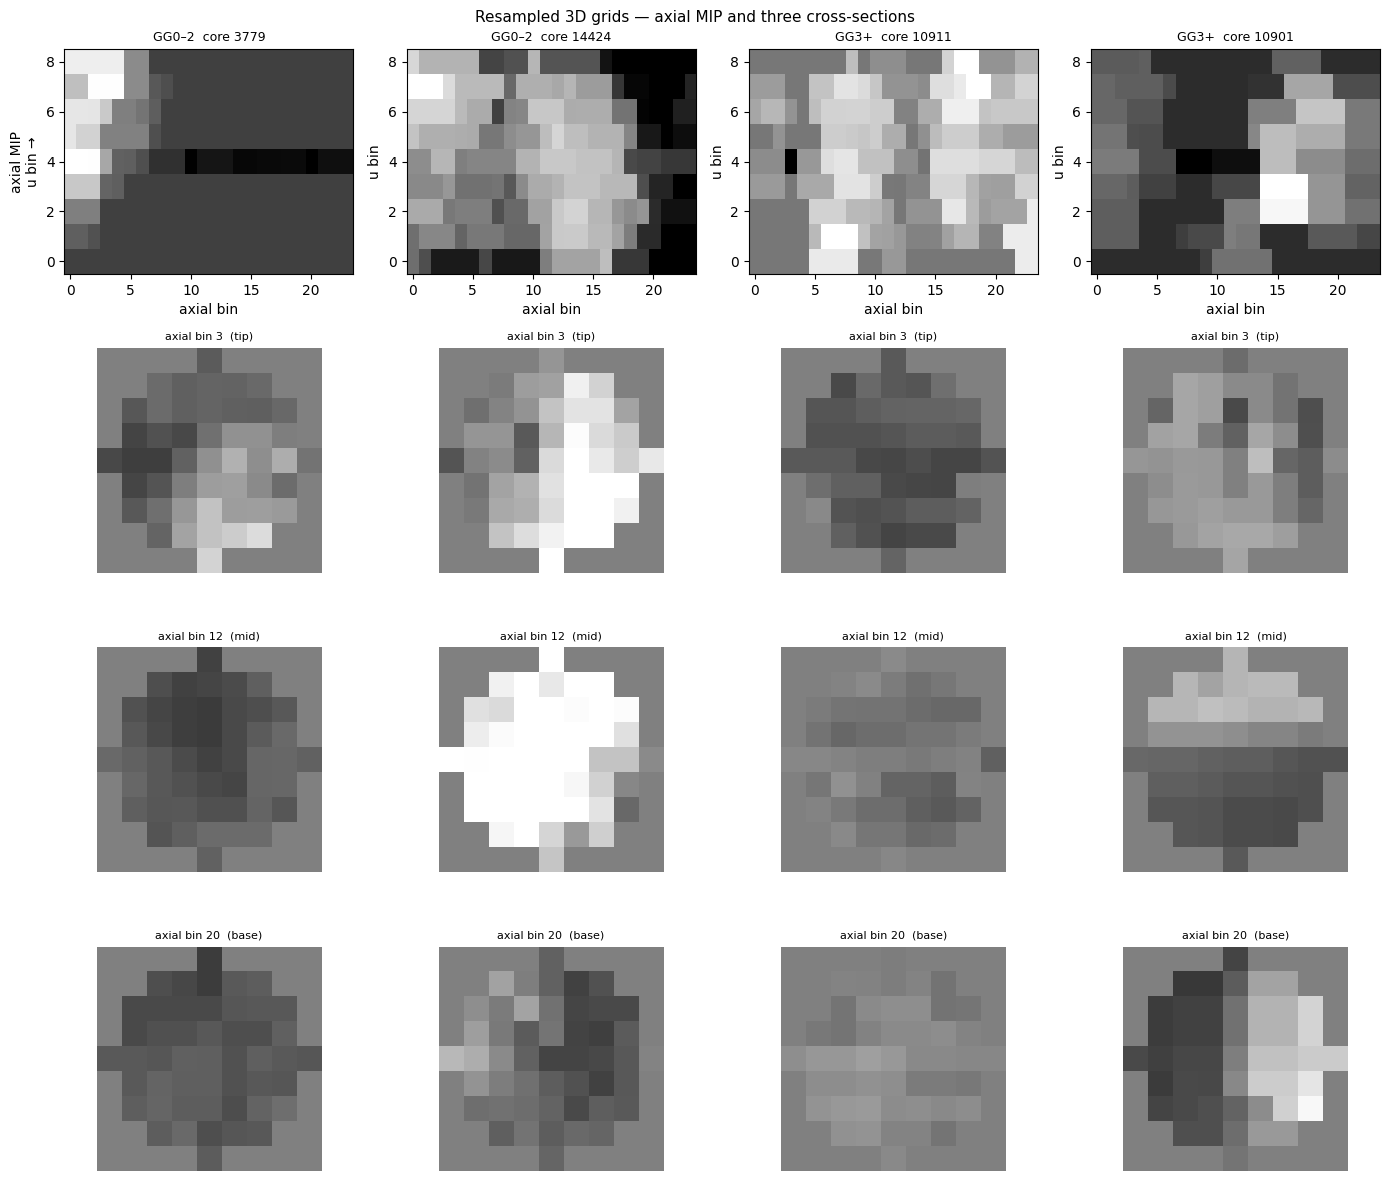

In [5]:
# Pick two GG0-2 and two GG3+ cores from trainval
tv = manifest[manifest['split'] == 'trainval']
samples = (
    tv[tv['label'] == 0].sample(2, random_state=0).assign(label_str='GG0–2')
    .__class__(pd.concat([
        tv[tv['label'] == 0].sample(2, random_state=0).assign(label_str='GG0–2'),
        tv[tv['label'] == 1].sample(2, random_state=0).assign(label_str='GG3+'),
    ]))
)
samples = pd.concat([
    tv[tv['label'] == 0].sample(2, random_state=1),
    tv[tv['label'] == 1].sample(2, random_state=1),
]).reset_index(drop=True)
label_strs = ['GG0–2', 'GG0–2', 'GG3+', 'GG3+']

fig, axes = plt.subplots(4, 4, figsize=(14, 12))
for col, (_, row) in enumerate(samples.iterrows()):
    d    = np.load(PATCHES_DIR / f"{int(row.core_id)}.npz")
    grid = resample_to_grid(d['coords'], d['intensity'])

    # Row 0: axial MIP (max over radial dims)
    axes[0, col].imshow(grid.max(axis=2).T, aspect='auto', cmap='gray', origin='lower')
    axes[0, col].set_title(f'{label_strs[col]}  core {int(row.core_id)}', fontsize=9)
    axes[0, col].set_xlabel('axial bin'); axes[0, col].set_ylabel('u bin')

    # Rows 1-3: three axial cross-sections (tip / mid / base)
    for r, frac in enumerate([0.15, 0.50, 0.85]):
        sl = int(frac * N_AXIAL)
        im = axes[r+1, col].imshow(grid[sl], cmap='gray', vmin=-2, vmax=2)
        axes[r+1, col].set_title(f'axial bin {sl}  ({["tip","mid","base"][r]})', fontsize=8)
        axes[r+1, col].axis('off')

axes[0, 0].set_ylabel('axial MIP\nu bin →')
for r, lbl in enumerate(['tip cross-section', 'mid cross-section', 'base cross-section']):
    axes[r+1, 0].set_ylabel(lbl, fontsize=8)

plt.suptitle('Resampled 3D grids — axial MIP and three cross-sections', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Dataset with augmentation

In [6]:
class BiopsyDataset(Dataset):
    """
    Loads precomputed grids from data/grids/{core_id}.npy.

    Augmentations (training only — all exact, no interpolation):
      - Random 90° rotation around needle axis: np.rot90 on the (u,v) plane.
        The 9×9 grid is square so 90° multiples are exact with no interpolation.
        This gives 4 discrete orientations, sufficient to enforce rotational invariance.
      - Random radial flip (u → -u): np.flip on axis 1
      - Intensity jitter: additive + multiplicative scalar noise
    """

    def __init__(self, core_ids, labels, grids_dir, augment=False):
        self.core_ids  = np.array(core_ids)
        self.labels    = np.array(labels, dtype=np.float32)
        self.grids_dir = Path(grids_dir)
        self.augment   = augment

    def __len__(self):
        return len(self.core_ids)

    def __getitem__(self, idx):
        grid = np.load(self.grids_dir / f'{self.core_ids[idx]}.npy')  # (24, 9, 9)

        if self.augment:
            # Random 90° rotation around needle axis (rotate the u-v plane)
            k = np.random.randint(0, 4)
            if k:
                grid = np.rot90(grid, k=k, axes=(1, 2)).copy()

            # Random radial flip
            if np.random.rand() < 0.5:
                grid = np.flip(grid, axis=1).copy()

            # Intensity jitter
            grid = grid + np.random.randn() * 0.05
            grid = grid * (1.0 + np.random.randn() * 0.05)

        x = torch.tensor(grid[None], dtype=torch.float32)   # (1, 24, 9, 9)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

## 4. Model — small 3D CNN

In [7]:
class BiopsyCNN(nn.Module):
    """
    Small 3D CNN for needle-aligned grids of shape (1, N_AXIAL, N_RADIAL, N_RADIAL).

    Verified shape trace (N_AXIAL=24, N_RADIAL=9):
      Input                              (B,  1, 24, 9, 9)
      [0]  Conv3d(1→16, k=3, pad=1)     (B, 16, 24, 9, 9)
      [3]  MaxPool3d((2,1,1))            (B, 16, 12, 9, 9)   axial ÷2
      [4]  Conv3d(16→32, k=3, pad=1)    (B, 32, 12, 9, 9)
      [7]  MaxPool3d((2,3,3))            (B, 32,  6, 3, 3)   axial ÷2, radial ÷3
      [8]  Conv3d(32→32, k=3, pad=1)    (B, 32,  6, 3, 3)
      [11] AvgPool3d(k=(3,3,3),stride=1)(B, 32,  4, 1, 1)   (6-3)/1+1=4, (3-3)/1+1=1
      Flatten                            (B, 128)
      Linear(128→32) → Linear(32→1)     (B, 1)  → squeeze → (B,)
    """

    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, padding=1, bias=False),   # 0
            nn.BatchNorm3d(16), nn.ReLU(inplace=True),                 # 1, 2
            nn.MaxPool3d(kernel_size=(2, 1, 1)),                       # 3

            nn.Conv3d(16, 32, kernel_size=3, padding=1, bias=False),   # 4
            nn.BatchNorm3d(32), nn.ReLU(inplace=True),                 # 5, 6
            nn.MaxPool3d(kernel_size=(2, 3, 3)),                       # 7

            nn.Conv3d(32, 32, kernel_size=3, padding=1, bias=False),   # 8
            nn.BatchNorm3d(32), nn.ReLU(inplace=True),                 # 9, 10
            nn.AvgPool3d(kernel_size=(3, 3, 3), stride=1),             # 11 → (32,4,1,1)
        )
        self.head = nn.Sequential(
            nn.Flatten(),                               # → 128
            nn.Dropout(0.5),
            nn.Linear(128, 32), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.encoder(x)).squeeze(1)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

_m = BiopsyCNN()
print(f'Parameters: {count_params(_m):,}')
_dummy = torch.zeros(2, 1, N_AXIAL, N_RADIAL, N_RADIAL)
with torch.no_grad():
    out = _m(_dummy)
print(f'Output shape: {tuple(out.shape)}  ✓')

Parameters: 46,225
Output shape: (2,)  ✓


## 5. Training utilities

In [12]:
from tqdm.notebook import tqdm

LOG_EVERY = 10   # print loss/AUC every N epochs

def run_epoch(model, loader, optimizer, pos_weight, device, train=True):
    model.train(train)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    total_loss, all_probs, all_labels = 0.0, [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss   = criterion(logits, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(y)
            all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.append(y.detach().cpu().numpy())

    probs  = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    auc    = roc_auc_score(labels, probs) if labels.sum() > 0 else 0.5
    return total_loss / len(loader.dataset), auc, probs


def train_fold(
    train_ids, train_labels,
    val_ids,   val_labels,
    grids_dir, device,
    n_epochs=100, batch_size=64, lr=1e-3,
    patience=20, weight_decay=1e-4,
):
    n_pos = int(train_labels.sum())
    n_neg = int((1 - train_labels).sum())
    pw    = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(device)

    train_ds = BiopsyDataset(train_ids, train_labels, grids_dir, augment=True)
    val_ds   = BiopsyDataset(val_ids,   val_labels,   grids_dir, augment=False)
    # num_workers=0: spawn multiprocessing can't pickle notebook-defined classes
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)

    model     = BiopsyCNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    best_auc, best_probs, no_improve = 0.0, None, 0
    history = []

    for epoch in tqdm(range(n_epochs), desc="Training"):
        tr_loss, tr_auc, _      = run_epoch(model, train_dl, optimizer, pw, device, train=True)
        va_loss, va_auc, v_prob = run_epoch(model, val_dl,   optimizer, pw, device, train=False)
        scheduler.step()
        history.append((tr_loss, tr_auc, va_loss, va_auc))

        if (epoch + 1) % LOG_EVERY == 0:
            print(f'  ep {epoch+1:3d}  '
                  f'tr loss={tr_loss:.4f} auc={tr_auc:.3f}  |  '
                  f'val loss={va_loss:.4f} auc={va_auc:.3f}')

        if va_auc > best_auc:
            best_auc, best_probs, no_improve = va_auc, v_prob, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  early stop at epoch {epoch+1}')
                break

    return best_auc, best_probs, val_labels, history, best_state

## 6. 5-fold cross-validation

In [13]:
tv_df = manifest[manifest['split'] == 'trainval'].reset_index(drop=True)

core_ids = tv_df['core_id'].values
labels   = tv_df['label'].values
groups   = tv_df['subject_id'].values

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

fold_aucs, fold_aps, all_histories = [], [], []

for fold, (tr_idx, va_idx) in enumerate(cv.split(core_ids, labels, groups=groups)):
    print(f'\nFold {fold+1}/5  '
          f'train pos={labels[tr_idx].sum()}  val pos={labels[va_idx].sum()}')

    best_auc, val_probs, val_labels, history, _ = train_fold(
        core_ids[tr_idx], labels[tr_idx].astype(np.float32),
        core_ids[va_idx], labels[va_idx].astype(np.float32),
        GRIDS_DIR, DEVICE,
        n_epochs=100, batch_size=64, lr=1e-3, patience=20,
    )
    ap = average_precision_score(val_labels, val_probs)
    fold_aucs.append(best_auc)
    fold_aps.append(ap)
    all_histories.append(history)
    print(f'  → best val AUC={best_auc:.3f}  AP={ap:.3f}')

print(f'\nCV ROC-AUC : {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}')
print(f'CV PR-AUC  : {np.mean(fold_aps):.3f} ± {np.std(fold_aps):.3f}')


Fold 1/5  train pos=416  val pos=105


Training:   0%|          | 0/100 [00:00<?, ?it/s]

  ep  10  tr loss=1.2578 auc=0.650  |  val loss=1.3512 auc=0.579
  ep  20  tr loss=1.2446 auc=0.668  |  val loss=1.4058 auc=0.540
  ep  30  tr loss=1.2314 auc=0.672  |  val loss=1.3857 auc=0.562
  early stop at epoch 30
  → best val AUC=0.579  AP=0.045

Fold 2/5  train pos=419  val pos=102


Training:   0%|          | 0/100 [00:00<?, ?it/s]

  ep  10  tr loss=1.2576 auc=0.656  |  val loss=1.2989 auc=0.584
  ep  20  tr loss=1.2451 auc=0.667  |  val loss=1.3214 auc=0.572
  early stop at epoch 26
  → best val AUC=0.585  AP=0.040

Fold 3/5  train pos=414  val pos=107


...

  ep  10  tr loss=1.2810 auc=0.628  |  val loss=1.3537 auc=0.559
  ep  20  tr loss=1.2560 auc=0.660  |  val loss=1.3564 auc=0.581
  early stop at epoch 26
  → best val AUC=0.621  AP=0.058

Fold 4/5  train pos=415  val pos=106


Training:   0%|          | 0/100 [00:00<?, ?it/s]

  ep  10  tr loss=1.2912 auc=0.623  |  val loss=1.2704 auc=0.677
  ep  20  tr loss=1.2905 auc=0.622  |  val loss=1.2550 auc=0.693
  early stop at epoch 22
  → best val AUC=0.714  AP=0.146

Fold 5/5  train pos=420  val pos=101


Training:   0%|          | 0/100 [00:00<?, ?it/s]

  ep  10  tr loss=1.2788 auc=0.628  |  val loss=1.2551 auc=0.641
  ep  20  tr loss=1.2718 auc=0.640  |  val loss=1.2548 auc=0.648
  early stop at epoch 26
  → best val AUC=0.650  AP=0.070

CV ROC-AUC : 0.630 ± 0.049
CV PR-AUC  : 0.072 ± 0.038


### Learning curves

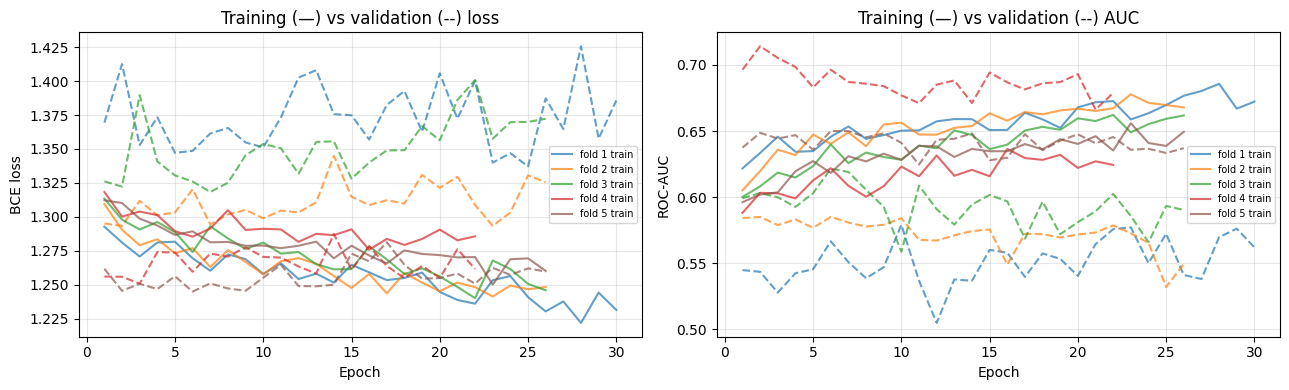

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = plt.cm.tab10(np.linspace(0, 0.5, 5))

for fold, hist in enumerate(all_histories):
    hist = np.array(hist)
    ep   = np.arange(1, len(hist) + 1)
    axes[0].plot(ep, hist[:, 0], color=colors[fold], alpha=0.7, label=f'fold {fold+1} train')
    axes[0].plot(ep, hist[:, 2], color=colors[fold], alpha=0.7, linestyle='--')
    axes[1].plot(ep, hist[:, 1], color=colors[fold], alpha=0.7, label=f'fold {fold+1} train')
    axes[1].plot(ep, hist[:, 3], color=colors[fold], alpha=0.7, linestyle='--')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE loss')
axes[0].set_title('Training (—) vs validation (--) loss')
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Training (—) vs validation (--) AUC')
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Final model — retrain on all trainval, evaluate on test

In [16]:
test_df  = manifest[manifest['split'] == 'test'].reset_index(drop=True)
test_ids = test_df['core_id'].values
y_test   = test_df['label'].values

median_epochs = int(np.median([len(h) for h in all_histories]))
final_epochs  = max(50, int(median_epochs * 1.1))
print(f'CV median stopping epoch: {median_epochs}  → final training: {final_epochs} epochs')

n_pos = int(labels.sum())
n_neg = int((1 - labels).sum())
pw    = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)

train_ds = BiopsyDataset(core_ids, labels.astype(np.float32), GRIDS_DIR, augment=True)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)

final_model = BiopsyCNN().to(DEVICE)
optimizer   = torch.optim.Adam(final_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=final_epochs)

for epoch in tqdm(range(final_epochs), desc="Final Training"):
    tr_loss, tr_auc, _ = run_epoch(final_model, train_dl, optimizer, pw, DEVICE, train=True)
    scheduler.step()
    if (epoch + 1) % LOG_EVERY == 0:
        print(f'  ep {epoch+1:3d}  loss={tr_loss:.4f}  auc={tr_auc:.3f}')

# Evaluate on test set
test_ds = BiopsyDataset(test_ids, y_test.astype(np.float32), GRIDS_DIR, augment=False)
test_dl = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=0)
_, test_auc, test_probs = run_epoch(final_model, test_dl, None, pw, DEVICE, train=False)
test_ap = average_precision_score(y_test, test_probs)

print(f'\nTest ROC-AUC : {test_auc:.3f}')
print(f'Test PR-AUC  : {test_ap:.3f}')

CV median stopping epoch: 26  → final training: 50 epochs


Final Training:   0%|          | 0/50 [00:00<?, ?it/s]

  ep  10  loss=1.2673  auc=0.641
  ep  20  loss=1.2677  auc=0.645
  ep  30  loss=1.2415  auc=0.669
  ep  40  loss=1.2157  auc=0.693
  ep  50  loss=1.2133  auc=0.694

Test ROC-AUC : 0.604
Test PR-AUC  : 0.068


## 8. Comparison with baseline

Model                            CV ROC-AUC  Test ROC-AUC  Test PR-AUC
----------------------------------------------------------------------
Logistic Regression (BL)        0.596±0.044         0.583        0.070
Random Forest (BL)              0.593±0.034         0.577        0.062
Gradient Boosting (BL)          0.571±0.036         0.571        0.070
3D CNN (this notebook)          0.630±0.049         0.604        0.068


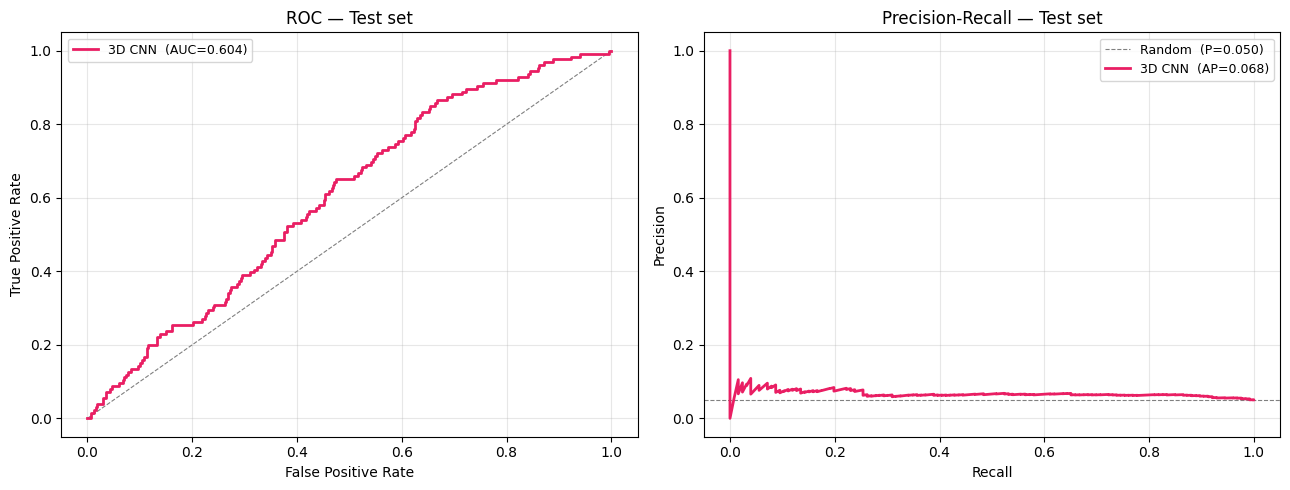

In [17]:
from sklearn.metrics import roc_curve, precision_recall_curve

print(f'{"Model":<30} {"CV ROC-AUC":>12} {"Test ROC-AUC":>13} {"Test PR-AUC":>12}')
print('-' * 70)
print(f'{"Logistic Regression (BL)":<30} {"0.596±0.044":>12} {"0.583":>13} {"0.070":>12}')
print(f'{"Random Forest (BL)":<30} {"0.593±0.034":>12} {"0.577":>13} {"0.062":>12}')
print(f'{"Gradient Boosting (BL)":<30} {"0.571±0.036":>12} {"0.571":>13} {"0.070":>12}')
print(f'{"3D CNN (this notebook)":<30} {f"{np.mean(fold_aucs):.3f}±{np.std(fold_aucs):.3f}":>12}'
      f' {test_auc:>13.3f} {test_ap:>12.3f}')

# ROC curves on test set
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot([0,1],[0,1],'--', color='gray', linewidth=0.8)
fpr, tpr, _ = roc_curve(y_test, test_probs)
ax.plot(fpr, tpr, color='#E91E63', linewidth=2,
        label=f'3D CNN  (AUC={test_auc:.3f})')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC — Test set'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
baseline_pr = y_test.mean()
ax.axhline(baseline_pr, linestyle='--', color='gray', linewidth=0.8,
           label=f'Random  (P={baseline_pr:.3f})')
prec, rec, _ = precision_recall_curve(y_test, test_probs)
ax.plot(rec, prec, color='#E91E63', linewidth=2,
        label=f'3D CNN  (AP={test_ap:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall — Test set'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/cnn_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Axial activation map

Which axial positions drive the prediction? Compute per-axial-bin mean absolute activation after block 3.

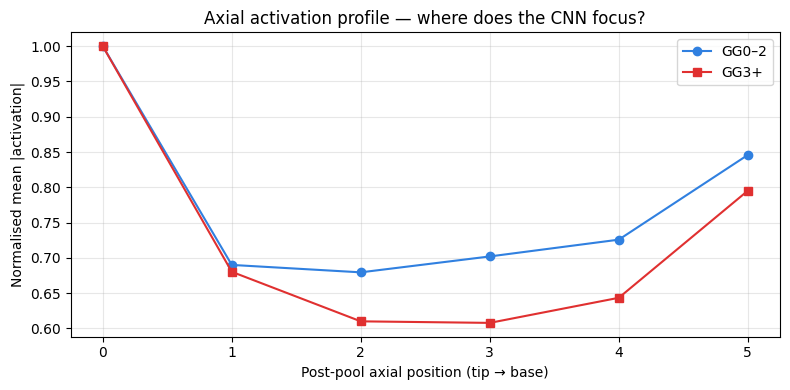

In [20]:
final_model.eval()
activations = {}

def hook_fn(module, inp, out):
    activations['feat'] = out.detach().cpu()

# Hook on the last ReLU of the encoder (index 10 — after block 3 BN+ReLU)
# At that point shape is (B, 32, 6, 3, 3), before AvgPool3d
handle = list(final_model.encoder.children())[10].register_forward_hook(hook_fn)

pos_acts, neg_acts = [], []
with torch.no_grad():
    for x, y in DataLoader(
        BiopsyDataset(test_ids, y_test.astype(np.float32), GRIDS_DIR, augment=False),
        batch_size=128, shuffle=False, num_workers=0
    ):
        _ = final_model(x.to(DEVICE))
        feat = activations['feat']          # (B, 32, 6, 3, 3)
        axial_energy = feat.abs().mean(dim=(1, 3, 4))  # (B, 6) — mean over C, u, v
        for i, label in enumerate(y.numpy()):
            if label == 1:
                pos_acts.append(axial_energy[i].numpy())
            else:
                neg_acts.append(axial_energy[i].numpy())

handle.remove()

pos_acts = np.array(pos_acts).mean(axis=0)
neg_acts = np.array(neg_acts).mean(axis=0)

x_bins = np.arange(len(pos_acts))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_bins, neg_acts / neg_acts.max(), 'o-', color='#3080e0', label='GG0–2')
ax.plot(x_bins, pos_acts / pos_acts.max(), 's-', color='#e03030', label='GG3+')
ax.set_xlabel('Post-pool axial position (tip → base)')
ax.set_ylabel('Normalised mean |activation|')
ax.set_title('Axial activation profile — where does the CNN focus?')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()